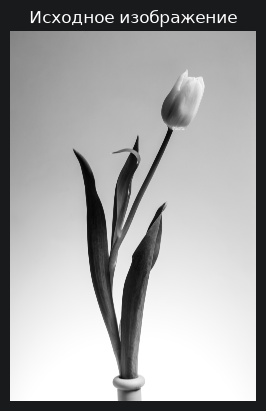

In [1]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("sar_1.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

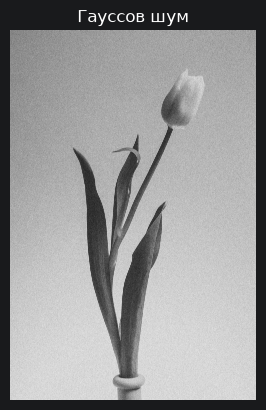

In [2]:
mean = 0
sigma = 100

gaussian_noise = np.random.normal(mean, sigma, img.shape)

gaussian_img = img.astype(np.float32) + gaussian_noise
gaussian_img = np.clip(gaussian_img, 0, 255).astype(np.uint8)

plt.imshow(gaussian_img, cmap="gray")
plt.title("Гауссов шум")
plt.axis("off")
plt.show()

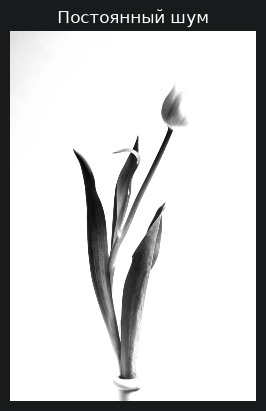

In [6]:
constant_value = 100

constant_img = img.astype(np.int16) + constant_value
constant_img = np.clip(constant_img, 0, 255).astype(np.uint8)

plt.imshow(constant_img, cmap="gray")
plt.title("Постоянный шум")
plt.axis("off")
plt.show()

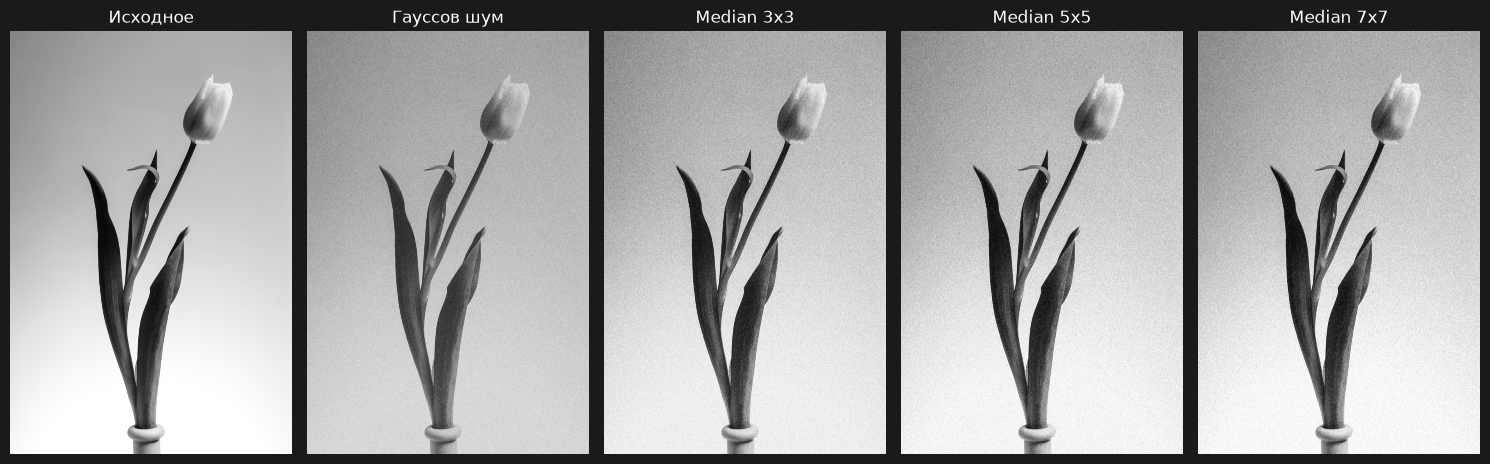

In [11]:
#Медианный
median3 = cv2.medianBlur(gaussian_img, 3)
median5 = cv2.medianBlur(gaussian_img, 5)
median7 = cv2.medianBlur(gaussian_img, 7)

plt.figure(figsize=(15,5))

images = [img, gaussian_img, median3, median5, median7]
titles = [
    "Исходное",
    "Гауссов шум",
    "Median 3x3",
    "Median 5x5",
    "Median 7x7"
]

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

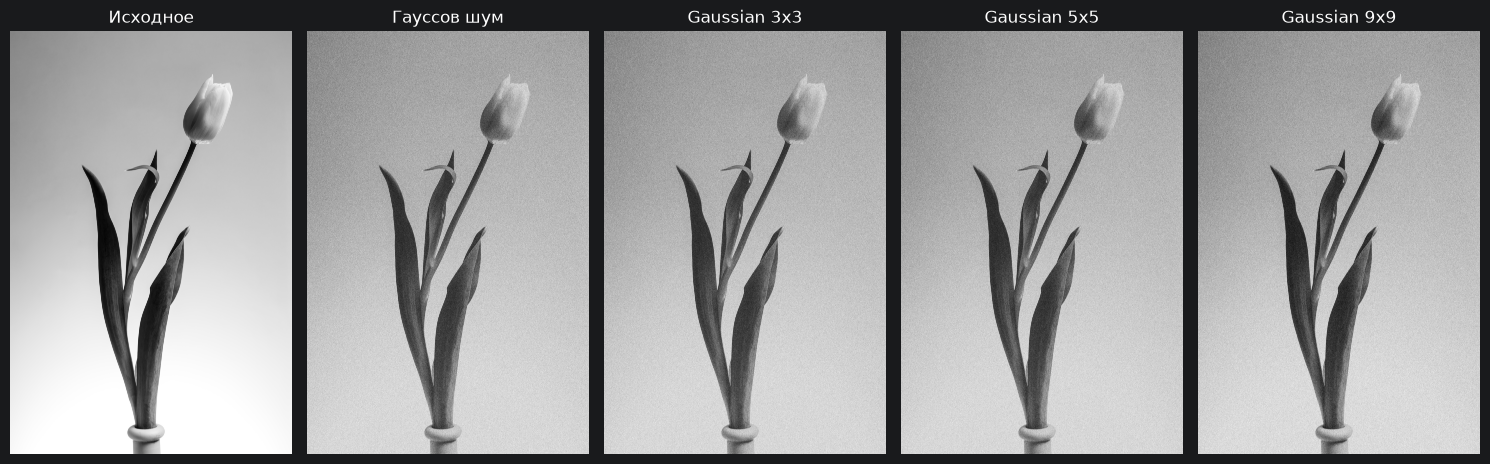

In [12]:
#Гауссов
gauss3 = cv2.GaussianBlur(gaussian_img, (3,3), 0)
gauss5 = cv2.GaussianBlur(gaussian_img, (5,5), 0)
gauss9 = cv2.GaussianBlur(gaussian_img, (9,9), 0)

plt.figure(figsize=(15,5))

images = [img, gaussian_img, gauss3, gauss5, gauss9]
titles = [
    "Исходное",
    "Гауссов шум",
    "Gaussian 3x3",
    "Gaussian 5x5",
    "Gaussian 9x9"
]

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

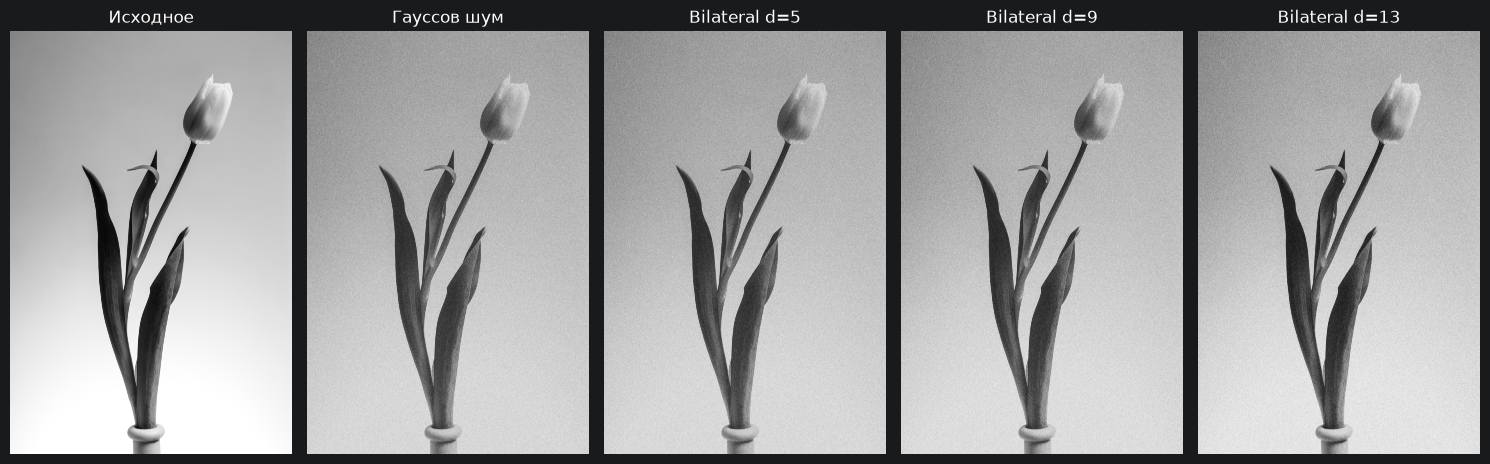

In [13]:
#Билатериальный
bil1 = cv2.bilateralFilter(gaussian_img, 5, 30, 30)
bil2 = cv2.bilateralFilter(gaussian_img, 9, 50, 50)
bil3 = cv2.bilateralFilter(gaussian_img, 13, 75, 75)

plt.figure(figsize=(15,5))

images = [img, gaussian_img, bil1, bil2, bil3]
titles = [
    "Исходное",
    "Гауссов шум",
    "Bilateral d=5",
    "Bilateral d=9",
    "Bilateral d=13"
]

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

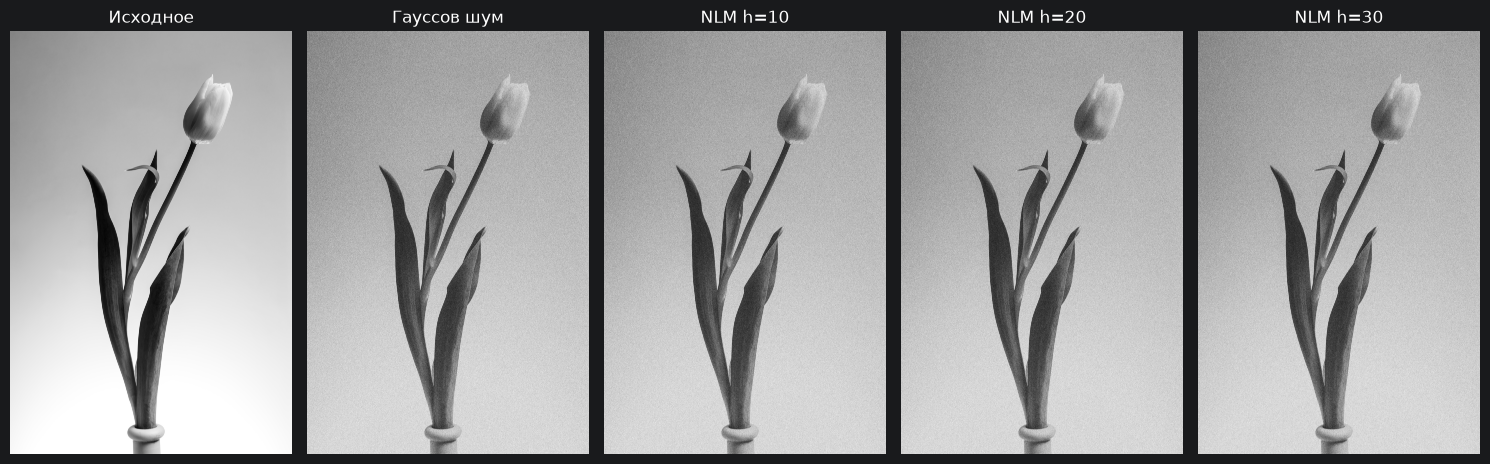

In [14]:
#Нелокальных средних
nlm1 = cv2.fastNlMeansDenoising(gaussian_img, None, 10, 7, 21)
nlm2 = cv2.fastNlMeansDenoising(gaussian_img, None, 20, 7, 21)
nlm3 = cv2.fastNlMeansDenoising(gaussian_img, None, 30, 7, 21)

plt.figure(figsize=(15,5))

images = [img, gaussian_img, nlm1, nlm2, nlm3]
titles = [
    "Исходное",
    "Гауссов шум",
    "NLM h=10",
    "NLM h=20",
    "NLM h=30"
]

for i in range(len(images)):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
#Вычислим лучший фильтр с помощью MSE SSIM
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

# Медианный фильтр (3x3)
mse = mean_squared_error(img.flatten(), median3.flatten())
ssim_value = ssim(img, median3, data_range=255)

print("Median 3x3")
print("MSE:", mse)
print("SSIM:", ssim_value)
print()


# Гауссов фильтр (3x3)
mse = mean_squared_error(img.flatten(), gauss3.flatten())
ssim_value = ssim(img, gauss3, data_range=255)

print("Gaussian 3x3")
print("MSE:", mse)
print("SSIM:", ssim_value)
print()


# Билатериальный фильтр
mse = mean_squared_error(img.flatten(), bil1.flatten())
ssim_value = ssim(img, bil1, data_range=255)

print("Bilateral")
print("MSE:", mse)
print("SSIM:", ssim_value)
print()


# Фильтр нелокальных средних
mse = mean_squared_error(img.flatten(), nlm1.flatten())
ssim_value = ssim(img, nlm1, data_range=255)

print("Non-local Means")
print("MSE:", mse)
print("SSIM:", ssim_value)

Median 3x3
MSE: 1296.0569947121724
SSIM: 0.07398509316381642

Gaussian 3x3
MSE: 1303.0529920006975
SSIM: 0.10448977033726849

Bilateral
MSE: 5081.158379112304
SSIM: 0.018010780803673545

Non-local Means
MSE: 5628.019318127568
SSIM: 0.016071679097997827


Наилучший результат показал фильтр нелокальных средних, поскольку он обеспечил наименьшее значение MSE и наибольшее значение SSIM среди протестированных методов.